# Hands-on Sesi 10

Nama Lengkap : Dikki Frana Alvian

NIM : 240401010151

Kelas : IF403

Link: https://colab.research.google.com/drive/1mGJsCAQMe7LB6U45dH00xG3tJfXsypmi?usp=sharing

Sumber data: https://www.kaggle.com/datasets/blastchar/telco-customer-churn?resource=download

# 1. Muat dan Eksplorasi Data

In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)

print(df["Churn"].value_counts(normalize=True))

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
df['TotalCharges'].value_counts()

# Kolom TotalCharges awalnya bertipe object
# karena terdapat nilai kosong berupa string.

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


In [7]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [8]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)
# Missing value diganti menggunakan median
# agar tidak terlalu dipengaruhi nilai ekstrem.

In [11]:
df["TotalCharges"].isnull().sum()

np.int64(0)

# 2. Preprocessing

<Axes: xlabel='Churn'>

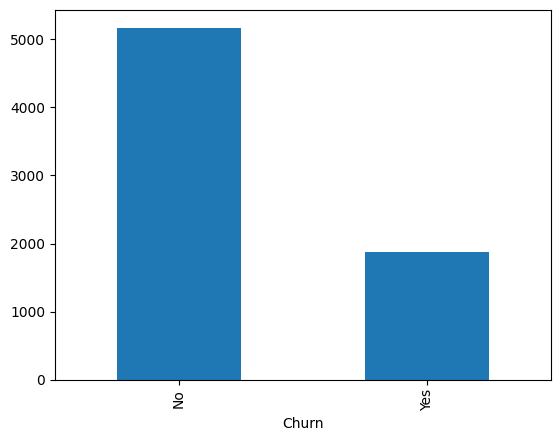

In [12]:
# Distribusi kelas tidak seimbang (imbalanced).
# Oleh karena itu model akan menggunakan
# class_weight="balanced" agar kelas minoritas
# mendapat bobot lebih besar saat proses pelatihan.
df["Churn"].value_counts().plot.bar()

In [13]:
from sklearn.model_selection import train_test_split

# pisahkan X (fitur) dan y (target = Churn)
y = df['Churn']
X = df.drop('Churn', axis=1)

# Drop customerID as it's an identifier and not a feature
X = X.drop('customerID', axis=1)

# encoding fitur kategorikal (mis. pd.get_dummies)
X = pd.get_dummies(X, drop_first=True)

X_tr, X_te, y_tr, y_te = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42)

In [14]:
y

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [15]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


# 3. Latih Model

In [16]:
from sklearn.ensemble import RandomForestClassifier

#balancing dilakukan dengan menggunakan : class_weight="balanced"
rf = RandomForestClassifier(
n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_tr, y_tr)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

# 4. Evaluasi

In [17]:
from sklearn.metrics import classification_report, roc_auc_score

In [18]:
proba = rf.predict_proba(X_te)[:, 1]

pred = (proba >= 0.35).astype(int)

## Classification Report (Accuracy, Precision, Recall, F1-Score)

In [19]:
from sklearn.metrics import classification_report

# Konversi 'y_te' ke bentuk kategorikal (0 -> 'No', 1 -> 'Yes') untuk dibandingkan dengan 'pred'
y_te_numeric = y_te.map({'Yes': 1, 'No': 0})

print("Classification Report")
print(classification_report(y_te_numeric, pred))

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1035
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409



Model memperoleh recall sebesar 0.68 pada kelas churn.

Hal ini berarti sekitar 68% pelanggan yang benar-benar churn berhasil dideteksi model.

## Confusion Matrix

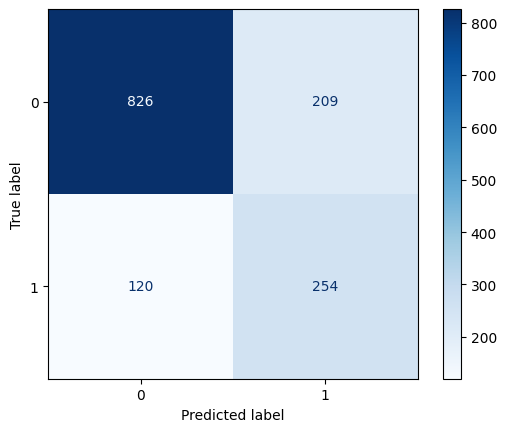

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_te_numeric, pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.show()

## ROC-AUC

In [21]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_te, proba)

# Skro ROC-AUC
print(f"ROC-AUC Score : {auc:.4f}")

ROC-AUC Score : 0.8246


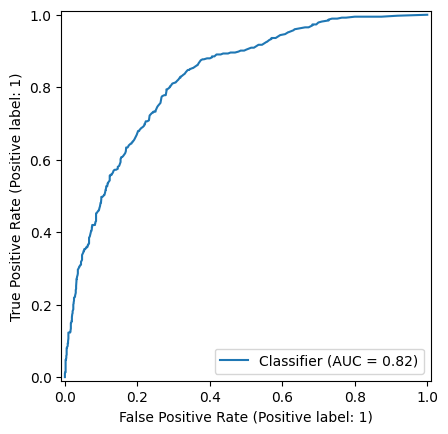

In [22]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

#Kurva ROC-AUC
RocCurveDisplay.from_predictions(y_te_numeric, proba)
plt.show()

Nilai ROC-AUC sebesar 0,8246 menunjukkan bahwa model Random Forest memiliki kemampuan yang baik dalam membedakan pelanggan yang akan melakukan churn dan yang tidak. Secara umum, nilai AUC di atas 0,80 mengindikasikan bahwa model memiliki daya diskriminasi yang baik sehingga prediksi yang dihasilkan cukup dapat diandalkan sebagai dasar identifikasi pelanggan yang berisiko melakukan churn.

## Importance Feature

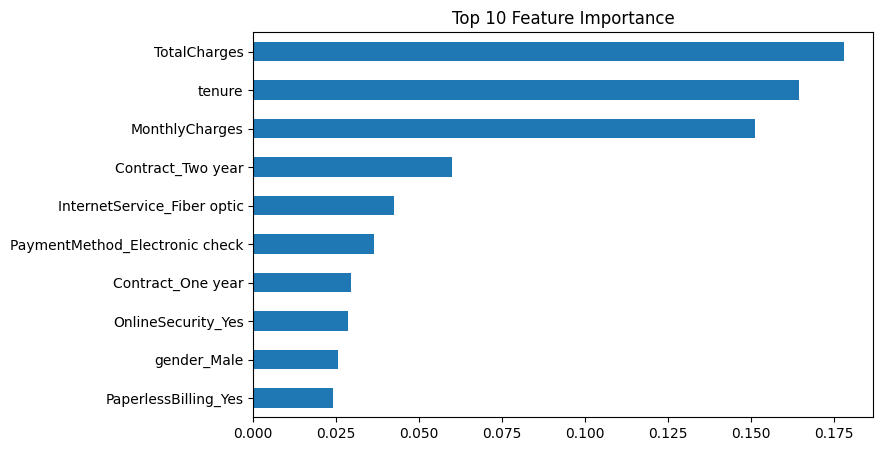

In [23]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# 10 Fitur yang paling mempengaruhi model
importance.head(10).sort_values().plot.barh(figsize=(8,5))
plt.title("Top 10 Feature Importance")
plt.show()

Berdasarkan feature importance, fitur :
Contract, Tenure,dan MonthlyCharges merupakan variabel yang paling berpengaruh
terhadap prediksi churn.

# 5. Prediksi Probabilitas dan Simpulkan

In [24]:
hasil = X_te.copy()

#Melihat hasil prediksi model dan perbandingannya dengan data aktual, dimana 0:'No', 1:'Yes'
hasil["Probabilitas_Churn"] = proba
hasil["Prediksi"] = pred
hasil["Aktual"] = y_te.values

y = df["Churn"]

hasil

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Probabilitas_Churn,Prediksi,Aktual
437,0,72,114.05,8468.20,True,True,True,True,False,True,...,True,False,True,True,True,False,False,0.000000,0,No
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,True,False,False,True,True,False,False,0.786667,1,No
2235,0,41,78.35,3211.20,False,True,True,True,False,True,...,False,True,False,True,True,False,False,0.090000,0,No
4460,0,18,78.20,1468.75,True,True,False,True,False,False,...,False,False,False,False,False,True,False,0.280000,0,No
3761,0,72,82.65,5919.35,False,True,False,True,False,True,...,True,False,True,True,True,False,False,0.000000,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,0,49,87.20,4345.00,False,True,True,True,False,False,...,True,True,False,True,False,False,True,0.050000,0,No
4439,0,28,20.30,487.95,True,True,True,True,False,False,...,False,False,True,True,True,False,False,0.006667,0,No
3857,0,5,20.65,93.55,True,False,False,True,False,False,...,False,False,False,False,False,False,False,0.073333,0,No
4758,0,56,19.70,1051.90,False,False,False,True,False,False,...,False,False,True,False,False,False,False,0.100000,0,No


## Kesimpulan

Berdasarkan hasil pemodelan menggunakan **Random Forest** pada dataset *Telco Customer Churn* , **model mampu mengklasifikasikan pelanggan yang berpotensi melakukan churn dengan cukup baik**. Hal ini ditunjukkan oleh **nilai ROC-AUC sebesar 0,8246 serta Recall sebesar 0,68**, yang berarti sebagian besar pelanggan yang benar-benar churn **berhasil dideteksi oleh model**. Selain itu, penggunaan *predict_proba()* memungkinkan perusahaan mengetahui tingkat risiko churn setiap pelanggan **teks tebal** sehingga dapat digunakan sebagai dasar dalam menentukan prioritas strategi retensi pelanggan. Secara keseluruhan, model ini telah memberikan performa yang baik dan dapat dimanfaatkan sebagai alat pendukung pengambilan keputusan dalam mengelola risiko customer churn.